In [4]:
import numpy as np
import pandas as pd
from setuptools.command.rotate import rotate

ser1 = pd.Series(data=[120, 380, 250, 360], index=['一季度', '二季度', '三季度', '四季度'])
ser1
## 标量运算
ser1+=10
ser1

一季度    130
二季度    390
三季度    260
四季度    370
dtype: int64

In [8]:
# 索引运算
ser1[2]
# 自定义索引
ser1["三季度"]
ser1

一季度    130
二季度    390
三季度    260
四季度    370
dtype: int64

In [9]:
print(ser1.dtype)                    # 数据类型
print(ser1.hasnans)                  # 有没有空值
print(ser1.index)                    # 索引
print(ser1.values)                   # 值
print(ser1.is_monotonic_increasing)  # 是否单调递增
print(ser1.is_unique) # 是否每个值都独一无二

int64
False
Index(['一季度', '二季度', '三季度', '四季度'], dtype='object')
[130 390 260 370]
False
True


In [10]:
## 统计相关
print(ser1.count())   # 计数
print(ser1.sum())     # 求和
print(ser1.mean())    # 求平均
print(ser1.median())  # 找中位数
print(ser1.max())     # 找最大
print(ser1.min())     # 找最小
print(ser1.std())     # 求标准差
print(ser1.var())     # 求方差
ser1.describe()

4
1150
287.5
315.0
390
130
119.54775893619531
14291.666666666666


count      4.000000
mean     287.500000
std      119.547759
min      130.000000
25%      227.500000
50%      315.000000
75%      375.000000
max      390.000000
dtype: float64

In [ ]:
ser8 = pd.Series(
    data=[35, 96, 12, 57, 25, 89],
    index=['grape', 'banana', 'pitaya', 'apple', 'peach', 'orange']
)
# 默认快排
ser8.sort_values()

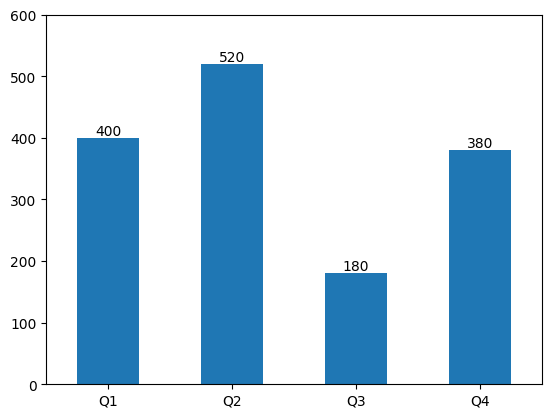

In [13]:
import matplotlib.pyplot as plt

ser9 = pd.Series({'Q1': 400, 'Q2': 520, 'Q3': 180, 'Q4': 380})
# 通过plot方法的kind指定图表类型为柱状图
ser9.plot(kind='bar')
# 定制纵轴的取值范围
plt.ylim(0, 600)
# 定制横轴刻度（旋转到0度）
plt.xticks(rotation=0)
# 为柱子增加数据标签
for i in range(ser9.size):
    plt.text(i, ser9[i] + 5, ser9[i], ha='center')
plt.show()

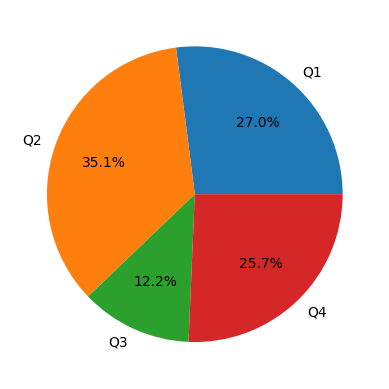

In [14]:
# plot方法的kind参数指定了图表类型为饼图
# autopct会自动计算并显示百分比
# pctdistance用来控制百分比到圆心的距离
ser9.plot(kind='pie', autopct='%.1f%%', pctdistance=0.65)
plt.show()

In [18]:
## 创建dataFrame对象
scores = np.random.randint(60, 101, (5, 3))
courses = ['语文','数学','英语']
stu_ids = np.arange(1001,1006)
df1 = pd.DataFrame(data=scores, columns=courses,index=stu_ids)
df1

,语文,数学,英语
1001,100,79,76
1002,75,62,73
1003,78,67,99
1004,88,90,100
1005,83,90,97


In [19]:
scores = {
    '语文': [62, 72, 93, 88, 93],
    '数学': [95, 65, 86, 66, 87],
    '英语': [66, 75, 82, 69, 82],
}
stu_ids = np.arange(1001, 1006)
df2 = pd.DataFrame(data=scores, index=stu_ids)
df2

,语文,数学,英语
1001,62,95,66
1002,72,65,75
1003,93,86,82
1004,88,66,69
1005,93,87,82


In [ ]:
import pymysql

# 创建一个MySQL数据库的连接对象
conn = pymysql.connect(
    host='101.42.16.8', port=3306,
    user='guest', password='Guest.618',
    database='hrs', charset='utf8mb4'
)
# 通过SQL从数据库二维表读取数据创建DataFrame
df5 = pd.read_sql('select * from tb_emp', conn, index_col='eno')
df5

In [ ]:
def detect_outliers_zscore(data,threshold=3):
    avg_value = np.mean(data)
    std_value = np.std(data)
    z_scor = np.abs(data - avg_value) / std_value
    return data[z_scor>threshold]

In [ ]:
##  IQR 方法中的 IQR（Inter-Quartile Range）代表四分位距离，即上四分位数（Q3）和下四分位数（Q1）的差值。通常情况下，可以认为小于Q1−1.5×IQR或大于 Q3+1.5×IQR的就是异常值，而这种检测异常值的方法也是箱线图（后面会讲到）默认使用的方法。下面的代码给出了如何通过 IQR 方法检测异常值
def detect_outliers_iqr(data, whis=1.5):
    q1, q3 = np.quantile(data, [0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - whis * iqr, q3 + whis * iqr
    return data[(data < lower) | (data > upper)]

In [20]:
scores = np.random.randint(50, 101, (5, 3))
names = ('关羽', '张飞', '赵云', '马超', '黄忠')
courses = ('语文', '数学', '英语')
df = pd.DataFrame(data=scores, columns=courses, index=names)
df


,语文,数学,英语
关羽,58,93,57
张飞,56,86,90
赵云,69,93,75
马超,59,53,62
黄忠,90,86,51


In [25]:
# 平均分
df.mean()
# 每个学生平均分
df.mean(axis=1)
# 方差
df.var()
#描述统计信息
df.describe()

关羽    93
张飞    86
赵云    93
马超    53
黄忠    86
Name: 数学, dtype: int64

In [26]:
# 排序取头部值
df.sort_values(by='语文',ascending=False)

,语文,数学,英语
黄忠,90,86,51
赵云,69,93,75
马超,59,53,62
关羽,58,93,57
张飞,56,86,90


In [27]:
df.nlargest(3,'语文')

,语文,数学,英语
黄忠,90,86,51
赵云,69,93,75
马超,59,53,62


In [30]:
sales_data = [6, 6, 7, 6, 8, 6]
index = pd.CategoricalIndex(
    data=['苹果', '香蕉', '苹果', '苹果', '桃子', '香蕉'],
    categories=['苹果', '香蕉', '桃子'],
    ordered=True
)
ser = pd.Series(data=sales_data, index=index)
ser
ser.groupby(level=0).sum()

# 指定索引的顺序
ser.index = index.reorder_categories(
    ['香蕉', '桃子', '苹果'])
ser.groupby(level=0).sum()

香蕉    12
桃子     8
苹果    19
dtype: int64

In [31]:
#时间索引
pd.date_range('2025-12-1','2026-05-01',periods=10)

DatetimeIndex(['2025-12-01 00:00:00', '2025-12-17 18:40:00',
               '2026-01-03 13:20:00', '2026-01-20 08:00:00',
               '2026-02-06 02:40:00', '2026-02-22 21:20:00',
               '2026-03-11 16:00:00', '2026-03-28 10:40:00',
               '2026-04-14 05:20:00', '2026-05-01 00:00:00'],
              dtype='datetime64[ns]', freq=None)

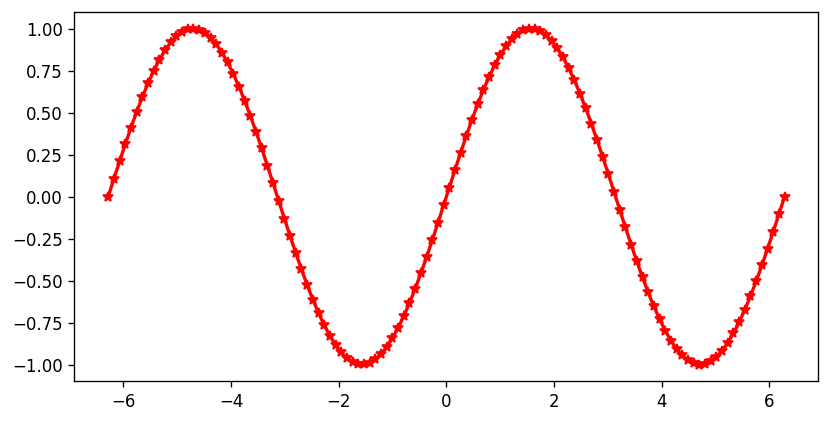

In [32]:
import numpy as np

x = np.linspace(-2 * np.pi, 2 * np.pi, 120)
y = np.sin(x)

# 创建画布
plt.figure(figsize=(8, 4), dpi=120)
# 绘制折线图
plt.plot(x, y, linewidth=2, marker='*', color='red')
# 显示绘图
plt.show()

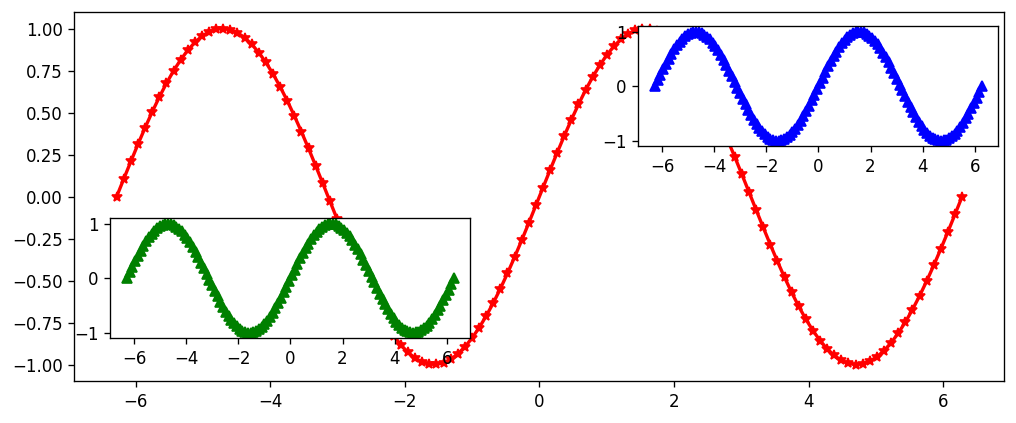

In [34]:
fig = plt.figure(figsize=(10, 4), dpi=120)
plt.plot(x, y, linewidth=2, marker='*', color='red')
# 用Figure对象的add_axes方法在现有坐标系中嵌套一个新的坐标系，该方法的参数是一个四元组，
# 代表了新坐标系在原坐标系中的位置，前两个值是左下角的位置，后两个值是坐标系的宽度和高度
ax = fig.add_axes((0.595, 0.6, 0.3,0.25))
ax.plot(x, y, marker='^', color='blue')
ax = fig.add_axes((0.155, 0.2, 0.3,0.25))
ax.plot(x, y, marker='^', color='green')
plt.show()

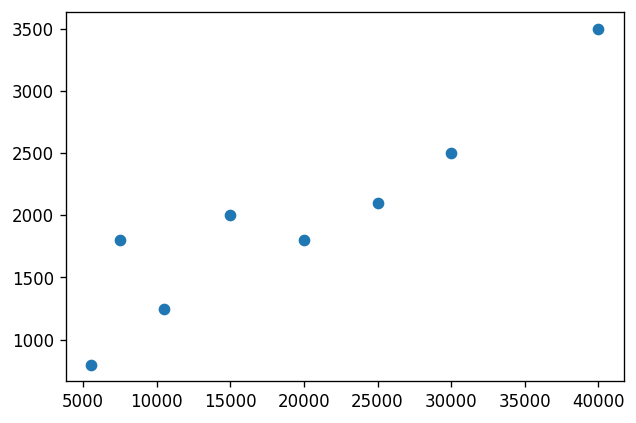

In [35]:
x = np.array([5550, 7500, 10500, 15000, 20000, 25000, 30000, 40000])
y = np.array([800, 1800, 1250, 2000, 1800, 2100, 2500, 3500])

plt.figure(figsize=(6, 4), dpi=120)
plt.scatter(x, y)
plt.show()

/opt/anaconda3/envs/dataScience/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 27700 (\N{CJK UNIFIED IDEOGRAPH-6C34}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/envs/dataScience/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 26524 (\N{CJK UNIFIED IDEOGRAPH-679C}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/envs/dataScience/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 38144 (\N{CJK UNIFIED IDEOGRAPH-9500}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/envs/dataScience/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 21806 (\N{CJK UNIFIED IDEOGRAPH-552E}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/envs/dataScience/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 39069 (\N{CJK

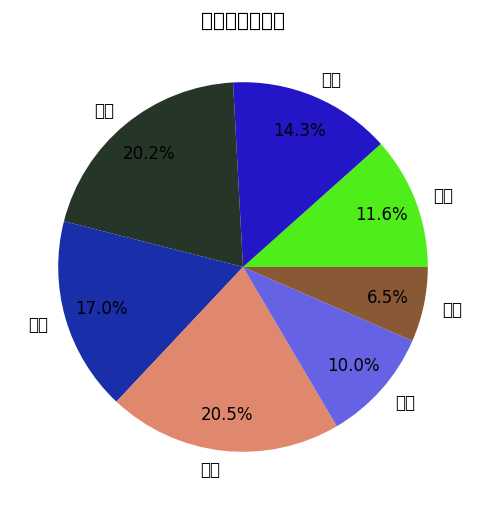

In [38]:
data = np.random.randint(100, 500, 7)
labels = ['苹果', '香蕉', '桃子', '荔枝', '石榴', '山竹', '榴莲']

plt.figure(figsize=(5, 5), dpi=120)
plt.pie(
    data,
    # 自动显示百分比
    autopct='%.1f%%',
    # 饼图的半径
    radius=1,
    # 百分比到圆心的距离
    pctdistance=0.8,
    # 颜色（随机生成）
    colors=np.random.rand(7, 3),
    # 分离距离
    # explode=[0.05, 0, 0.1, 0, 0, 0, 0],
    # 阴影效果
    # shadow=True,
    # 字体属性
    #textprops=dict(fontsize=8, color='black'),
    # 楔子属性（生成环状饼图的关键）
    #wedgeprops=dict(linewidth=1, width=0.35),
    # 标签
    labels=labels
)
# 定制图表的标题
plt.title('水果销售额占比')
plt.show()

/opt/anaconda3/envs/dataScience/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 36523 (\N{CJK UNIFIED IDEOGRAPH-8EAB}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/envs/dataScience/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 39640 (\N{CJK UNIFIED IDEOGRAPH-9AD8}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/envs/dataScience/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 27010 (\N{CJK UNIFIED IDEOGRAPH-6982}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/envs/dataScience/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/envs/dataScience/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 23494 (\N{CJK

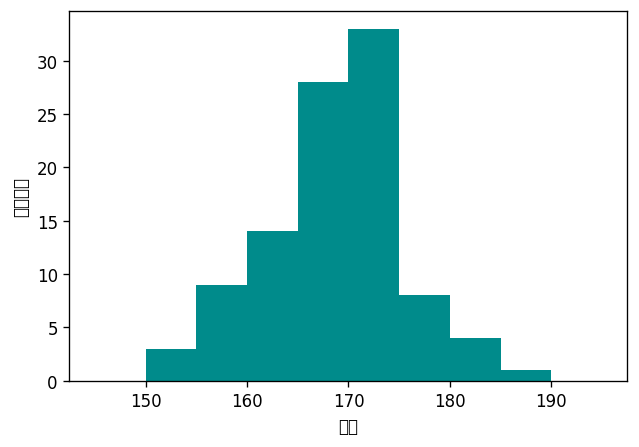

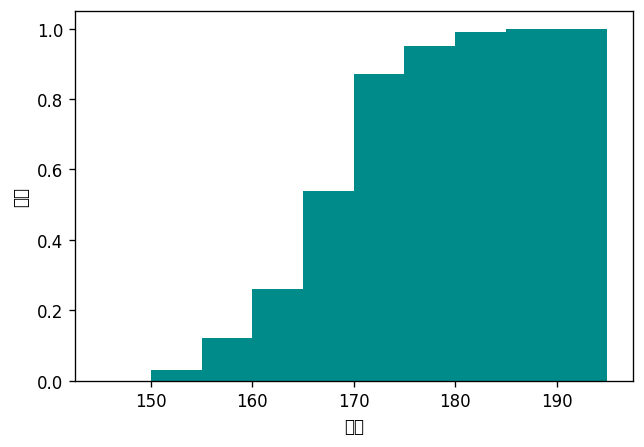

In [41]:
heights = np.array([
    170, 163, 174, 164, 159, 168, 165, 171, 171, 167,
    165, 161, 175, 170, 174, 170, 174, 170, 173, 173,
    167, 169, 173, 153, 165, 169, 158, 166, 164, 173,
    162, 171, 173, 171, 165, 152, 163, 170, 171, 163,
    165, 166, 155, 155, 171, 161, 167, 172, 164, 155,
    168, 171, 173, 169, 165, 162, 168, 177, 174, 178,
    161, 180, 155, 155, 166, 175, 159, 169, 165, 174,
    175, 160, 152, 168, 164, 175, 168, 183, 166, 166,
    182, 174, 167, 168, 176, 170, 169, 173, 177, 168,
    172, 159, 173, 185, 161, 170, 170, 184, 171, 172
])
plt.figure(figsize=(6, 4), dpi=120)
# 绘制直方图
plt.hist(heights, bins=np.arange(145, 196, 5), color='darkcyan')
# 定制横轴标签
plt.xlabel('身高')
# 定制纵轴标签
plt.ylabel('概率密度')
plt.show()

plt.figure(figsize=(6, 4), dpi=120)
# 绘制直方图
plt.hist(heights, bins=np.arange(145, 196, 5), color='darkcyan', density=True, cumulative=True)
# 定制横轴标签
plt.xlabel('身高')
# 定制纵轴标签
plt.ylabel('概率')
plt.show()

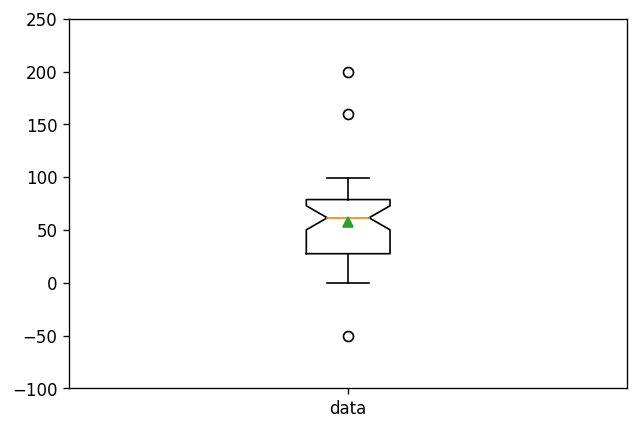

In [42]:
# 数组中有47个[0, 100)范围的随机数
data = np.random.randint(0, 100, 47)
# 向数组中添加三个可能是离群点的数据
data = np.append(data, 160)
data = np.append(data, 200)
data = np.append(data, -50)

plt.figure(figsize=(6, 4), dpi=120)
# whis参数的默认值是1.5，将其设置为3可以检测极端离群值，showmeans=True表示在图中标记均值的位置
plt.boxplot(data, whis=1.5, showmeans=True, notch=True)
# 定制纵轴的取值范围
plt.ylim([-100, 250])
# 定制横轴的刻度
plt.xticks([1], labels=['data'])
plt.show()

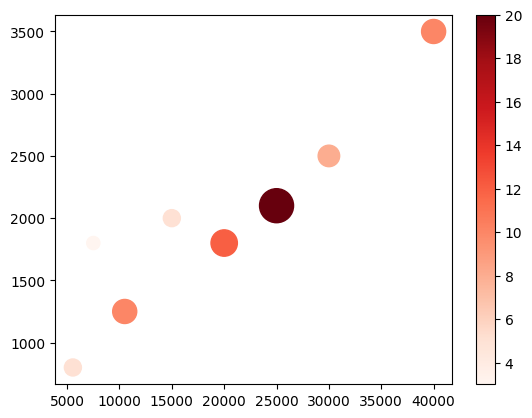

/opt/anaconda3/envs/dataScience/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 26143 (\N{CJK UNIFIED IDEOGRAPH-661F}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/envs/dataScience/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 26399 (\N{CJK UNIFIED IDEOGRAPH-671F}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/envs/dataScience/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 19968 (\N{CJK UNIFIED IDEOGRAPH-4E00}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/envs/dataScience/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 20108 (\N{CJK UNIFIED IDEOGRAPH-4E8C}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/envs/dataScience/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 19977 (\N{CJK

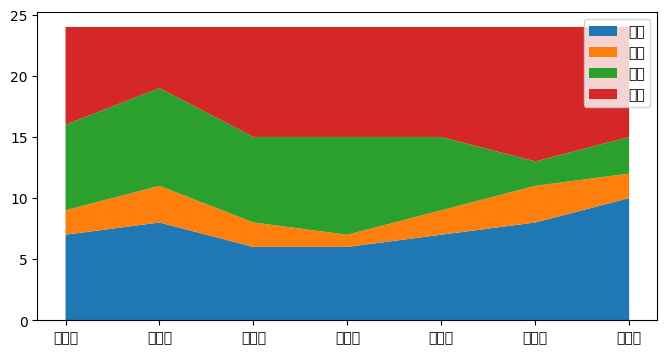

In [45]:
income = np.array([5550, 7500, 10500, 15000, 20000, 25000, 30000, 40000])
outcome = np.array([800, 1800, 1250, 2000, 1800, 2100, 2500, 3500])
nums = np.array([5, 3, 10, 5, 12, 20, 8, 10])

# 通过scatter函数的s参数和c参数分别控制面积和颜色
plt.scatter(income, outcome, s=nums * 30, c=nums, cmap='Reds')
# 显示颜色条
plt.colorbar()
# 显示图表
plt.show()


/opt/anaconda3/envs/dataScience/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 26143 (\N{CJK UNIFIED IDEOGRAPH-661F}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/envs/dataScience/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 26399 (\N{CJK UNIFIED IDEOGRAPH-671F}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/envs/dataScience/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 19968 (\N{CJK UNIFIED IDEOGRAPH-4E00}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/envs/dataScience/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 20108 (\N{CJK UNIFIED IDEOGRAPH-4E8C}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/envs/dataScience/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 19977 (\N{CJK

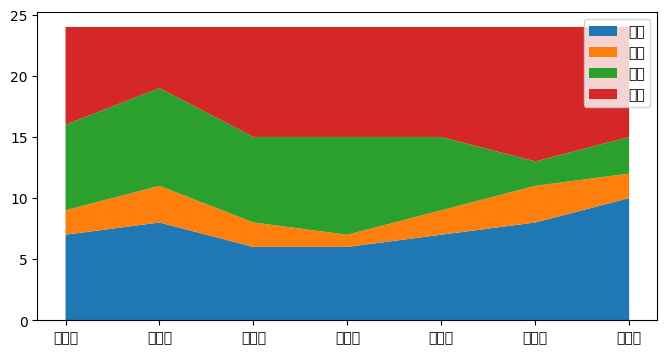

In [46]:
plt.figure(figsize=(8, 4))
days = np.arange(7)
sleeping = [7, 8, 6, 6, 7, 8, 10]
eating = [2, 3, 2, 1, 2, 3, 2]
working = [7, 8, 7, 8, 6, 2, 3]
playing = [8, 5, 9, 9, 9, 11, 9]
# 绘制堆叠折线图
plt.stackplot(days, sleeping, eating, working, playing)
# 定制横轴刻度
plt.xticks(days, labels=[f'星期{x}' for x in '一二三四五六日'])
# 定制图例
plt.legend(['睡觉', '吃饭', '工作', '玩耍'], fontsize=10)
# 显示图表
plt.show()

/opt/anaconda3/envs/dataScience/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 39532 (\N{CJK UNIFIED IDEOGRAPH-9A6C}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/envs/dataScience/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 40857 (\N{CJK UNIFIED IDEOGRAPH-9F99}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/envs/dataScience/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 27700 (\N{CJK UNIFIED IDEOGRAPH-6C34}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/envs/dataScience/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 35895 (\N{CJK UNIFIED IDEOGRAPH-8C37}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/envs/dataScience/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 38588 (\N{CJK

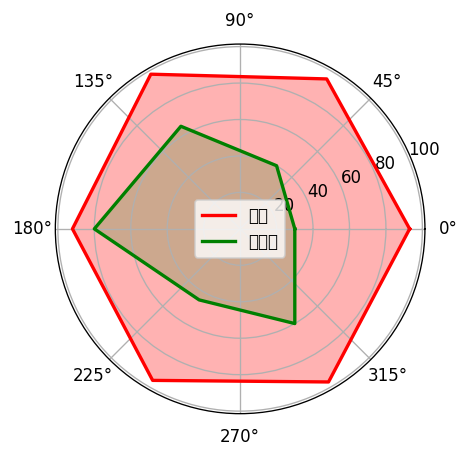

In [47]:
labels = np.array(['速度', '力量', '经验', '防守', '发球', '技术'])
# 马龙和水谷隼的数据
malong_values = np.array([93, 95, 98, 92, 96, 97])
shuigu_values = np.array([30, 40, 65, 80, 45, 60])
angles = np.linspace(0, 2 * np.pi, labels.size, endpoint=False)
# 多加一条数据让图形闭合
malong_values = np.append(malong_values, malong_values[0])
shuigu_values = np.append(shuigu_values, shuigu_values[0])
angles = np.append(angles, angles[0])
# 创建画布
plt.figure(figsize=(4, 4), dpi=120)
# 创建坐标系
ax = plt.subplot(projection='polar')
# 绘图和填充
plt.plot(angles, malong_values, color='r', linewidth=2, label='马龙')
plt.fill(angles, malong_values, color='r', alpha=0.3)
plt.plot(angles, shuigu_values, color='g', linewidth=2, label='水谷隼')
plt.fill(angles, shuigu_values, color='g', alpha=0.2)
# 显示图例
ax.legend()
# 显示图表
plt.show()

/opt/anaconda3/envs/dataScience/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 32452 (\N{CJK UNIFIED IDEOGRAPH-7EC4}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


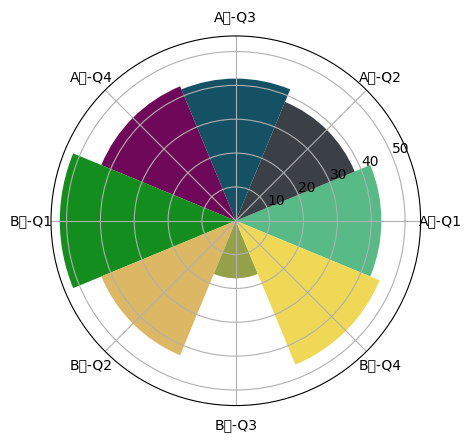

In [48]:
group1 = np.random.randint(20, 50, 4)
group2 = np.random.randint(10, 60, 4)
x = np.array([f'A组-Q{i}' for i in range(1, 5)] + [f'B组-Q{i}' for i in range(1, 5)])
y = np.array(group1.tolist() + group2.tolist())
# 玫瑰花瓣的角度和宽度
theta = np.linspace(0, 2 * np.pi, x.size, endpoint=False)
width = 2 * np.pi / x.size
# 生成8种随机颜色
colors = np.random.rand(8, 3)
# 将柱状图投影到极坐标
ax = plt.subplot(projection='polar')
# 绘制柱状图
plt.bar(theta, y, width=width, color=colors, bottom=0)
# 设置网格
ax.set_thetagrids(theta * 180 / np.pi, x, fontsize=10)
# 显示图表
plt.show()

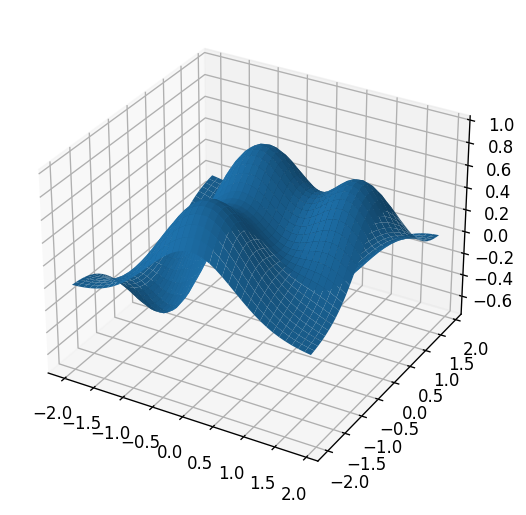

In [54]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8, 4), dpi=120)
# 创建3D坐标系并添加到画布上
ax = Axes3D(fig, auto_add_to_figure=False)
fig.add_axes(ax)
x = np.arange(-2, 2, 0.1)
y = np.arange(-2, 2, 0.1)
x, y = np.meshgrid(x, y)
z = (1 - y ** 5 + x ** 5) * np.exp(-x ** 2 - y ** 2)
# 绘制3D曲面
ax.plot_surface(x, y, z)
# 显示图表
plt.show()

In [55]:
%matplotlib qt


ImportError: Failed to import any of the following Qt binding modules: PyQt6, PySide6, PyQt5, PySide2

In [56]:
from sklearn.datasets import load_iris

# 加载鸢尾花数据集
iris = load_iris()
# 查看数据集的介绍
print(iris.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

    :Number of Instances: 150 (50 in each of three classes)
    :Number of Attributes: 4 numeric, predictive attributes and the class
    :Attribute Information:
        - sepal length in cm
        - sepal width in cm
        - petal length in cm
        - petal width in cm
        - class:
                - Iris-Setosa
                - Iris-Versicolour
                - Iris-Virginica
                
    :Summary Statistics:

    ============== ==== ==== ======= ===== ====================
                    Min  Max   Mean    SD   Class Correlation
    ============== ==== ==== ======= ===== ====================
    sepal length:   4.3  7.9   5.84   0.83    0.7826
    sepal width:    2.0  4.4   3.05   0.43   -0.4194
    petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
    petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
    ============== ==== ==== ======= ===== ===========

In [58]:
# 特征（150行4列的二维数组，分别是花萼长、花萼宽、花瓣长、花瓣宽）
X = iris.data
# 标签（150个元素的一维数组，包含0、1、2三个值分别代表三种鸢尾花）
y = iris.target
x,y

(array([[-2. , -1.9, -1.8, ...,  1.7,  1.8,  1.9],
        [-2. , -1.9, -1.8, ...,  1.7,  1.8,  1.9],
        [-2. , -1.9, -1.8, ...,  1.7,  1.8,  1.9],
        ...,
        [-2. , -1.9, -1.8, ...,  1.7,  1.8,  1.9],
        [-2. , -1.9, -1.8, ...,  1.7,  1.8,  1.9],
        [-2. , -1.9, -1.8, ...,  1.7,  1.8,  1.9]]),
 array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]))